In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
!pip install grad-cam

In [3]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import cv2

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [5]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [6]:
dataset_path = "/content/drive/MyDrive/Dataset/Dataset"

full_dataset = datasets.ImageFolder(
    dataset_path,
    transform=transform
)

test_loader = DataLoader(
    full_dataset,
    batch_size=1,
    shuffle=True
)

print("Classes:", full_dataset.classes)

Classes: ['F0', 'F1', 'F2', 'F3', 'F4']


In [18]:
model = models.efficientnet_b0(pretrained=False)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    5
)

model.load_state_dict(torch.load(
"/content/drive/MyDrive/best_EfficientNet.pth",
map_location=device
))

model = model.to(device)
model.eval()

print("EfficientNet loaded successfully")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


EfficientNet loaded successfully


In [19]:
from pytorch_grad_cam import GradCAM, ScoreCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [20]:
target_layer = model.features[-1]

In [21]:
gradcam = GradCAM(
    model=model,
    target_layers=[target_layer]
)

scorecam = ScoreCAM(
    model=model,
    target_layers=[target_layer]
)

In [22]:
images, labels = next(iter(test_loader))

input_tensor = images.to(device)

# GradCAM
grad_cam_map = gradcam(input_tensor=input_tensor)[0]

# ScoreCAM
score_cam_map = scorecam(input_tensor=input_tensor)[0]

img = images[0].permute(1,2,0).numpy()

img = (img - img.min()) / (img.max() - img.min())

grad_img = show_cam_on_image(img, grad_cam_map, use_rgb=True)
score_img = show_cam_on_image(img, score_cam_map, use_rgb=True)

100%|██████████| 80/80 [01:31<00:00,  1.14s/it]


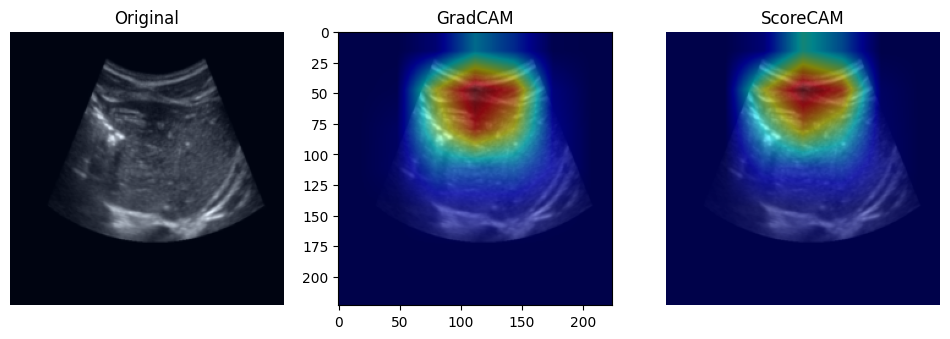

In [23]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(grad_img)
plt.title("GradCAM")

plt.subplot(1,3,3)
plt.imshow(score_img)
plt.title("ScoreCAM")
plt.axis("off")

plt.show()

In [24]:
from pytorch_grad_cam import GradCAMPlusPlus, ScoreCAM

In [25]:
target_layer = model.features[-1]

gradcampp = GradCAMPlusPlus(
    model=model,
    target_layers=[target_layer]
)

scorecam = ScoreCAM(
    model=model,
    target_layers=[target_layer]
)

In [26]:
gradcampp_map = gradcampp(input_tensor=input_tensor)[0]

scorecam_map = scorecam(input_tensor=input_tensor)[0]

100%|██████████| 80/80 [01:31<00:00,  1.14s/it]


In [27]:
gradpp_img = show_cam_on_image(img, gradcampp_map, use_rgb=True)

score_img = show_cam_on_image(img, scorecam_map, use_rgb=True)

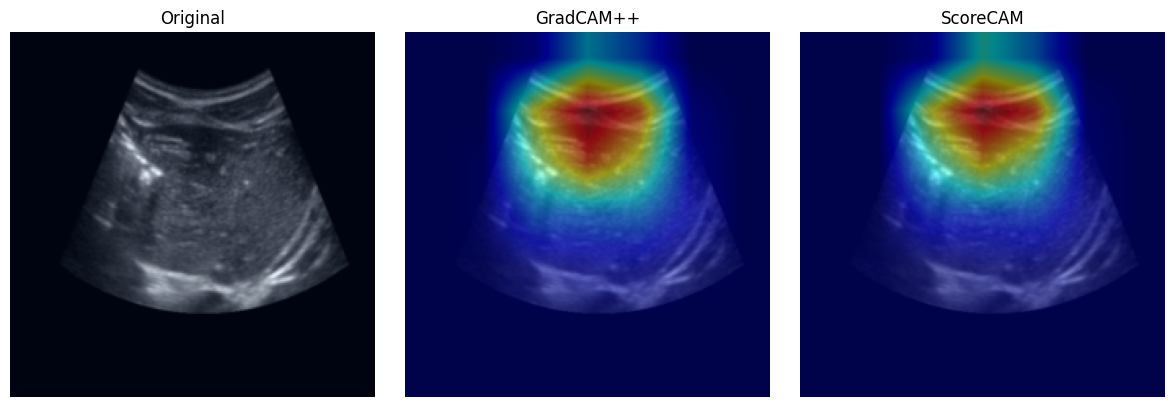

In [28]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(gradpp_img)
plt.title("GradCAM++")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(score_img)
plt.title("ScoreCAM")
plt.axis('off')

plt.tight_layout()
plt.show()

In [33]:
from torchvision import datasets, transforms

dataset_path = "/content/drive/MyDrive/Dataset/Dataset"

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

dataset = datasets.ImageFolder(dataset_path, transform=transform)

print("Classes:", dataset.classes)

Classes: ['F0', 'F1', 'F2', 'F3', 'F4']


In [34]:
stage_images = {}
class_names = dataset.classes

for img, label in dataset:

    stage = int(label)

    if stage not in stage_images:
        stage_images[stage] = img

    if len(stage_images) == len(class_names):
        break

print("Stages collected:", stage_images.keys())

Stages collected: dict_keys([0, 1, 2, 3, 4])


100%|██████████| 80/80 [01:28<00:00,  1.10s/it]


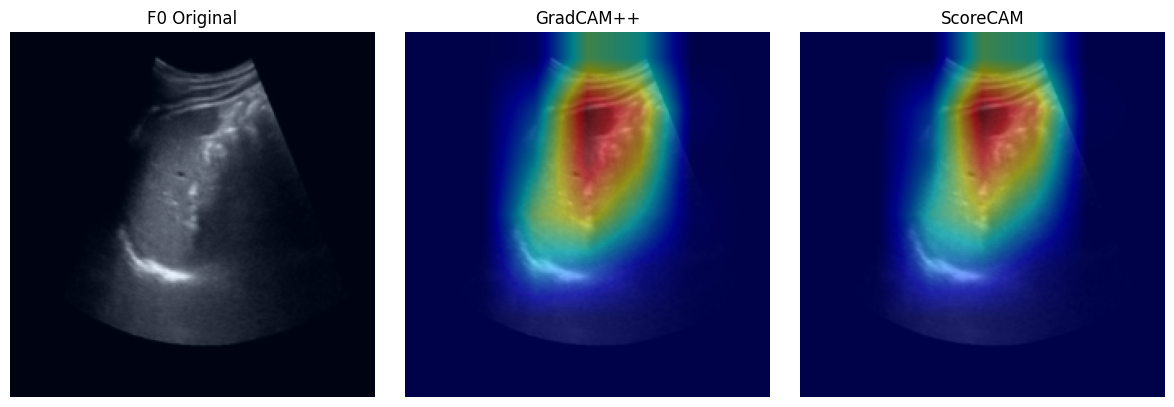

100%|██████████| 80/80 [01:26<00:00,  1.08s/it]


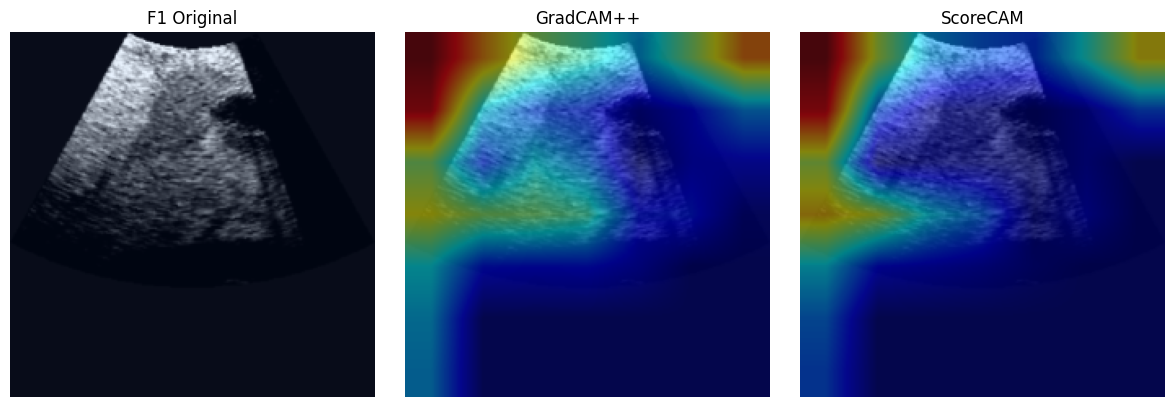

100%|██████████| 80/80 [01:27<00:00,  1.10s/it]


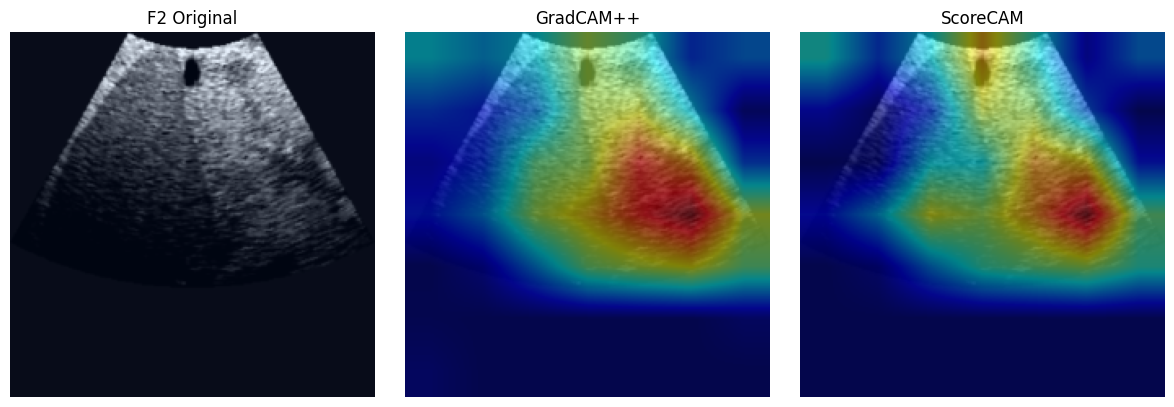

100%|██████████| 80/80 [01:36<00:00,  1.21s/it]


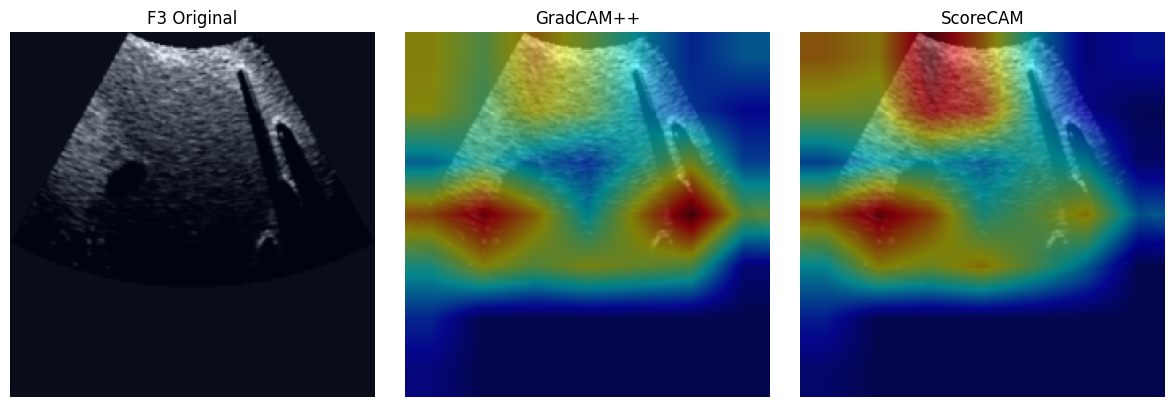

100%|██████████| 80/80 [01:27<00:00,  1.10s/it]


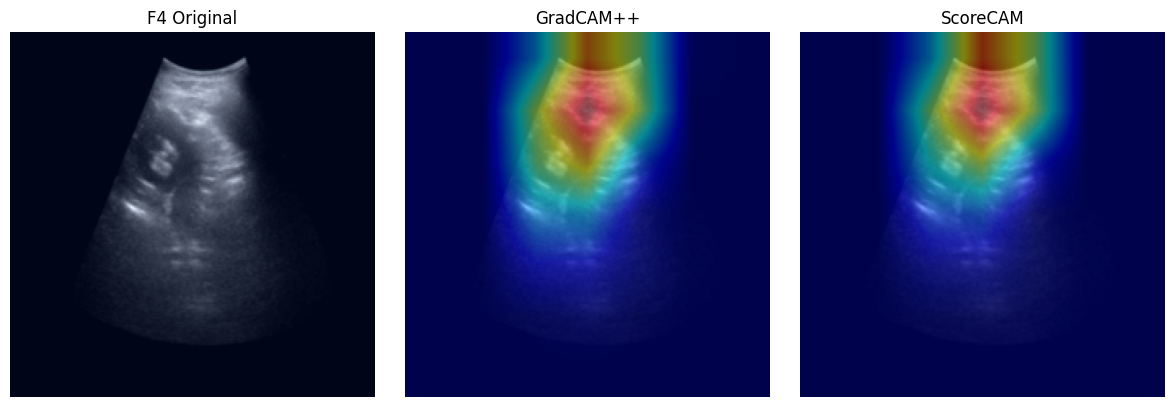

In [35]:
for stage, image in stage_images.items():

    input_tensor = image.unsqueeze(0).to(device)

    grad_map = gradcampp(input_tensor=input_tensor)[0]

    score_map = scorecam(input_tensor=input_tensor)[0]

    img = image.permute(1,2,0).numpy()
    img = (img - img.min())/(img.max()-img.min())

    grad_img = show_cam_on_image(img, grad_map, use_rgb=True)
    score_img = show_cam_on_image(img, score_map, use_rgb=True)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title(f"{class_names[stage]} Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(grad_img)
    plt.title("GradCAM++")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(score_img)
    plt.title("ScoreCAM")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

100%|██████████| 80/80 [01:29<00:00,  1.12s/it]


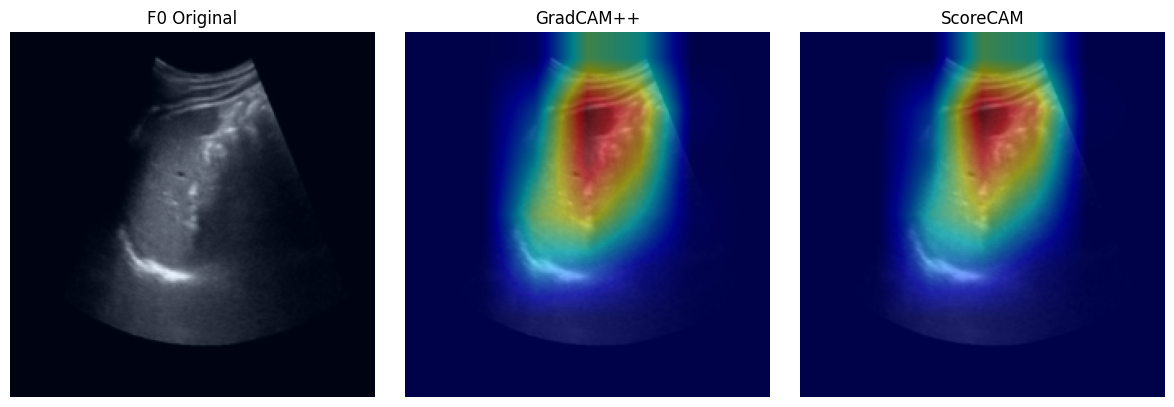

100%|██████████| 80/80 [01:34<00:00,  1.18s/it]


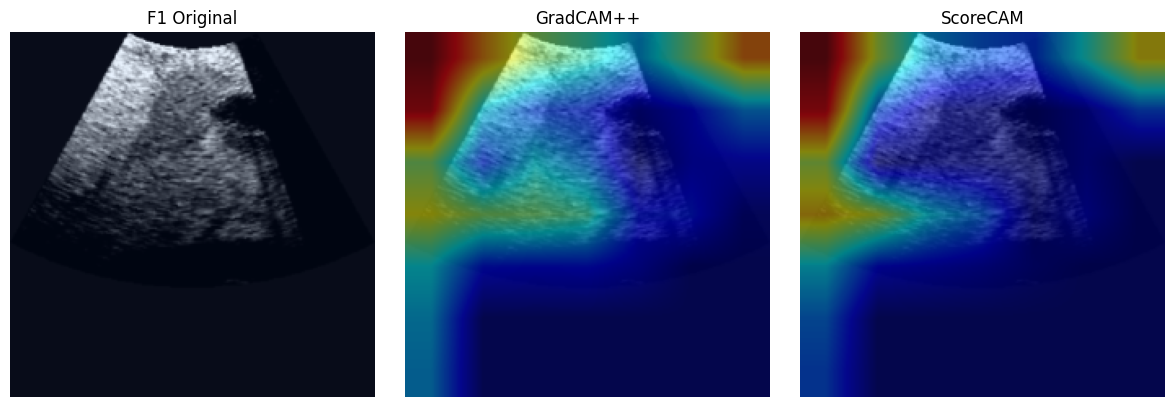

100%|██████████| 80/80 [01:32<00:00,  1.16s/it]


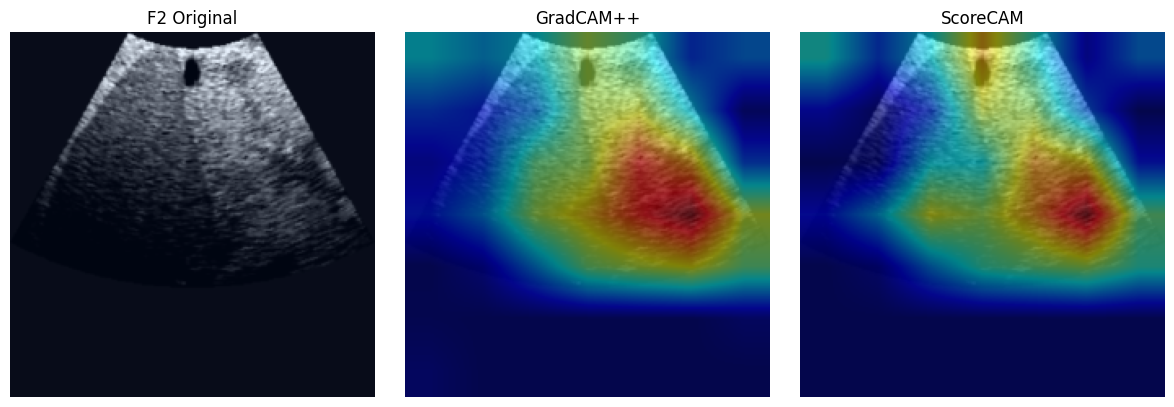

100%|██████████| 80/80 [01:32<00:00,  1.15s/it]


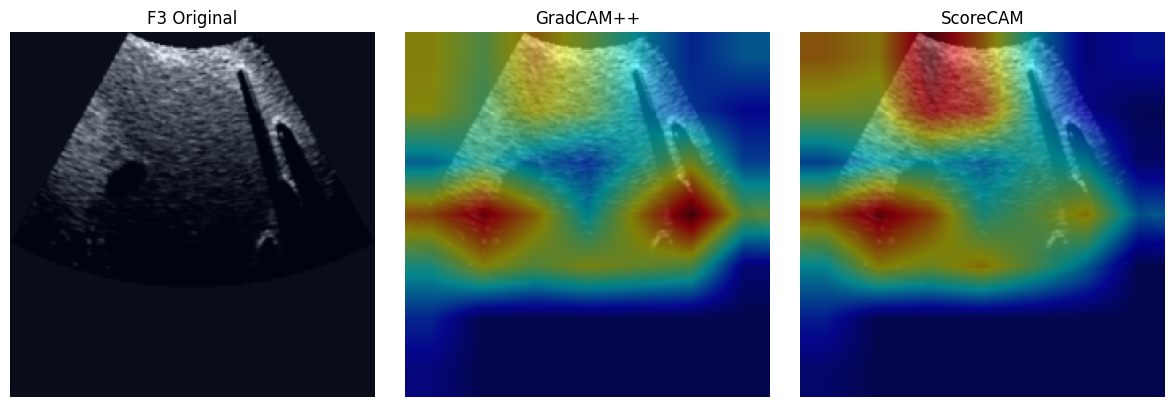

100%|██████████| 80/80 [01:32<00:00,  1.16s/it]


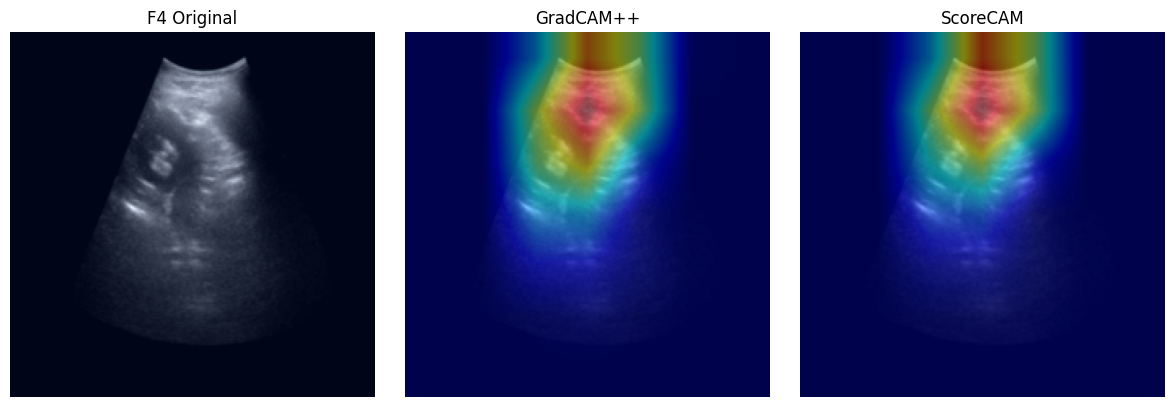

In [37]:
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

for stage in stage_images:

    image = stage_images[stage]

    input_tensor = image.unsqueeze(0).to(device)

    # Get predicted class
    output = model(input_tensor)
    pred_class = output.argmax(dim=1).item()

    targets = [ClassifierOutputTarget(pred_class)]

    # Generate CAM maps
    grad_map = gradcampp(input_tensor=input_tensor, targets=targets)[0]
    score_map = scorecam(input_tensor=input_tensor, targets=targets)[0]

    # Convert tensor image to numpy
    img = image.permute(1,2,0).cpu().numpy()
    img = (img - img.min())/(img.max()-img.min())

    # Overlay CAM
    grad_img = show_cam_on_image(img, grad_map, use_rgb=True)
    score_img = show_cam_on_image(img, score_map, use_rgb=True)

    # Plot results
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title(f"{class_names[stage]} Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(grad_img)
    plt.title("GradCAM++")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(score_img)
    plt.title("ScoreCAM")
    plt.axis('off')

    plt.tight_layout()
    plt.show()